# 04 — Uncertainty Visualization

> **"A forecast without uncertainty is not a forecast. It is a fiction."**

---

Mọi dự báo đều có sai số. Mọi estimate đều có khoảng tin cậy.
Nhưng phần lớn chart chỉ hiển thị **đường trung tâm** — ẩn đi toàn bộ uncertainty.

Điều này dẫn đến:
- Người xem **overconfident** vào forecast
- Quyết định bỏ qua downside risk
- Khi forecast sai, mất niềm tin vào toàn bộ hệ thống

**Uncertainty Visualization** là kỹ thuật hiển thị trung thực phạm vi của điều không biết.

### Nội dung notebook này:

1. **Confidence Band** — Khoảng tin cậy của estimate
2. **Prediction Interval** — Khoảng dự báo cho observation mới
3. **CI vs PI** — Sự khác biệt và khi nào dùng cái nào
4. **Forecast Shading** — Phân biệt actual vs projected
5. **Fan Chart** — Multi-quantile uncertainty visualization
6. **Scenario Analysis** — Best / Base / Worst case
7. **Uncertainty Grows Over Time** — Tại sao band nở rộng theo thời gian
8. **Honest vs Misleading Forecast Charts**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.uncertainty import (
    add_confidence_band,
    add_prediction_interval,
    add_dual_interval,
    shade_forecast_period,
    add_forecast_region,
    fan_chart,
)
from vizint.perception import highlight_series, fade_series
from vizint.annotation import add_note, add_caption, annotate_with_arrow
from vizint.context import add_reference_line

np.random.seed(42)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo 3 tập dữ liệu:
1. **Regression line** — actual + fitted + CI + PI
2. **Time series forecast** — historical + projected với uncertainty band
3. **Quantile forecast** — GDP forecast với 5 quantiles cho fan chart

In [2]:
# --- Dataset 1: Regression data ---
n = 80
x_reg = np.linspace(0, 10, n)
true_slope, true_intercept = 2.5, 5.0
y_reg = true_slope * x_reg + true_intercept + np.random.randn(n) * 4.0

# OLS fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_reg, y_reg)
y_fitted = slope * x_reg + intercept

# CI and PI for regression
n_pts = len(x_reg)
x_mean = x_reg.mean()
SSx = np.sum((x_reg - x_mean) ** 2)
s_res = np.sqrt(np.sum((y_reg - y_fitted) ** 2) / (n_pts - 2))  # residual std
t_crit = stats.t.ppf(0.975, df=n_pts - 2)  # 95%

se_mean = s_res * np.sqrt(1/n_pts + (x_reg - x_mean)**2 / SSx)  # SE of mean
se_pred = s_res * np.sqrt(1 + 1/n_pts + (x_reg - x_mean)**2 / SSx)  # SE of prediction

ci_lower = y_fitted - t_crit * se_mean
ci_upper = y_fitted + t_crit * se_mean
pi_lower = y_fitted - t_crit * se_pred
pi_upper = y_fitted + t_crit * se_pred

# --- Dataset 2: Time series with forecast ---
T_hist = 48   # 4 years historical
T_fore = 12   # 1 year forecast
T_total = T_hist + T_fore

t_hist = np.arange(T_hist)
t_fore = np.arange(T_hist, T_total)

# Historical
y_hist = 100 + np.linspace(0, 40, T_hist) + np.random.randn(T_hist) * 3

# Forecast central + uncertainty grows over time
y_fore_central = y_hist[-1] + np.linspace(0, 15, T_fore)
fore_std = np.linspace(2, 10, T_fore)   # uncertainty widens
fore_ci_lo = y_fore_central - 1.96 * fore_std
fore_ci_hi = y_fore_central + 1.96 * fore_std
fore_pi_lo = y_fore_central - 2.58 * fore_std
fore_pi_hi = y_fore_central + 2.58 * fore_std

# --- Dataset 3: Fan chart quantiles ---
T_fan = 12
t_fan = np.arange(T_fan)
central = 6.5 + np.linspace(0, 0.5, T_fan) + np.random.randn(T_fan) * 0.1

spread = np.linspace(0, 1, T_fan)
quantile_data = pd.DataFrame({
    'q10': central - 2.0 * spread,
    'q20': central - 1.4 * spread,
    'q30': central - 0.9 * spread,
    'q40': central - 0.4 * spread,
    'q50': central,
    'q60': central + 0.4 * spread,
    'q70': central + 0.9 * spread,
    'q80': central + 1.4 * spread,
    'q90': central + 2.0 * spread,
})

print(f'Regression pts : {n}')
print(f'Time series    : {T_hist} historical + {T_fore} forecast')
print(f'Fan chart      : {T_fan} quarters, 9 quantiles')

Regression pts : 80
Time series    : 48 historical + 12 forecast
Fan chart      : 12 quarters, 9 quantiles


## 1. Confidence Band

**Confidence Interval (CI)** là khoảng tin cậy của **parameter estimate**,
thường dùng cho mean hoặc regression line.

Nếu lặp lại experiment nhiều lần, khoảng tin cậy mức $1-\alpha$ sẽ chứa
true parameter với xác suất:

$$
P(\theta \in \text{CI}) = 1 - \alpha
$$

Ví dụ:

$$
95\% \text{ CI} \Rightarrow \alpha = 0.05
$$

---

### Confidence Band trong Regression

Giả sử fitted regression:

$$
\hat y(x)
$$

Confidence band là khoảng:

$$
\hat y(x)
\pm
t_{\alpha/2}
\cdot
\text{SE}(\hat y(x))
$$

Trong đó:

- $\hat y(x)$ : fitted mean
- $\text{SE}(\hat y(x))$ : standard error của mean
- $t_{\alpha/2}$ : critical value

---

### Standard Error của Fitted Mean

Standard error của regression mean:

$$
\text{SE}(\hat y(x))
=
\sigma
\sqrt{
\frac{1}{n}
+
\frac{(x-\bar x)^2}{\sum (x_i-\bar x)^2}
}
$$

Trong đó:

- $\sigma$ : residual std
- $\bar x$ : mean của $x$
- $n$ : số samples

---

### Vì sao CI band thắt ở giữa

Tại trung tâm:

$$
x = \bar x
$$

thì:

$$
(x-\bar x)^2 = 0
$$

Do đó:

$$
\text{SE}(\hat y(x))
=
\sigma \sqrt{\frac{1}{n}}
$$

→ nhỏ nhất

Nên confidence band **hẹp nhất tại trung tâm**.

---

### Vì sao CI mở rộng ở hai đầu

Khi $x$ xa trung tâm:

$$
(x-\bar x)^2 \uparrow
$$

⇒

$$
\text{SE}(\hat y(x)) \uparrow
$$

⇒

Confidence band mở rộng.

Nguyên nhân:

- ít dữ liệu ở rìa
- extrapolation uncertainty cao

---

### CI band biểu diễn

Confidence band:

$$
\text{Lower}(x)
=
\hat y(x)
-
t_{\alpha/2}
\cdot
\text{SE}(\hat y(x))
$$

$$
\text{Upper}(x)
=
\hat y(x)
+
t_{\alpha/2}
\cdot
\text{SE}(\hat y(x))
$$

---

### Interpretation

CI band thể hiện:

- uncertainty của fitted mean
- không phải uncertainty của dữ liệu
- không phải prediction interval

Nếu band hẹp:

$$
\text{SE}(\hat y) \downarrow
$$

→ estimate chắc chắn

Nếu band rộng:

$$
\text{SE}(\hat y) \uparrow
$$

→ estimate không chắc chắn

---

### Confidence Band vs Prediction Band

Confidence band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction band:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Prediction band luôn rộng hơn.

---

### Summary

Confidence band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Đặc điểm:

- hẹp nhất tại $x=\bar x$
- rộng ở hai đầu
- thể hiện uncertainty của mean
- không phải uncertainty của điểm mới  

C:\Users\Duy\AppData\Local\Temp\ipykernel_10584\2274333922.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


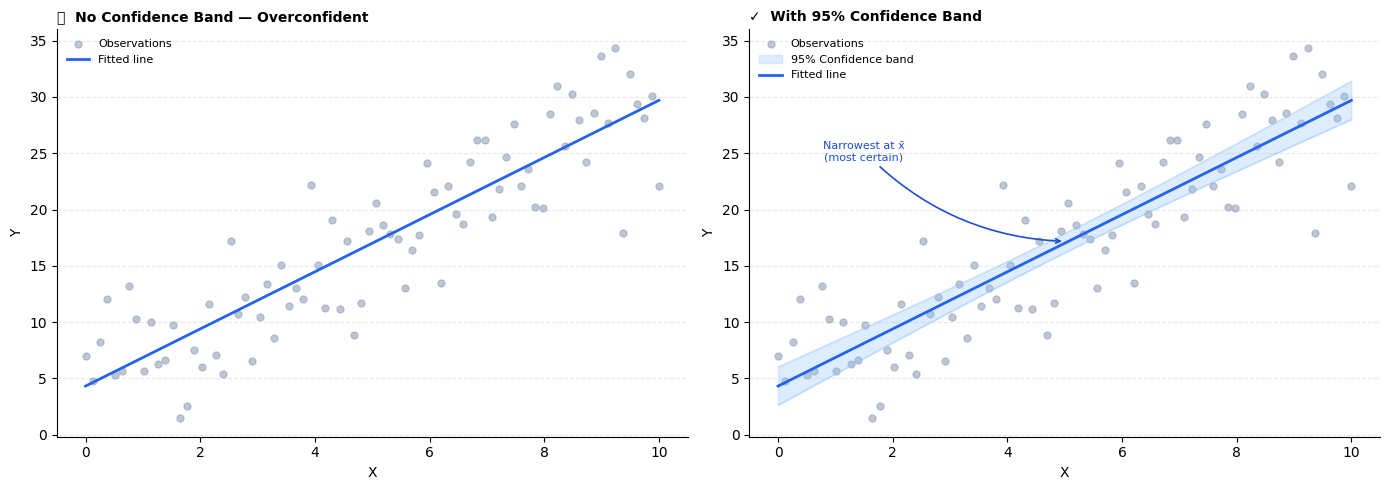

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Panel 1: Without CI — hides uncertainty
ax = axes[0]
ax.scatter(x_reg, y_reg, color='#94A3B8', s=25, alpha=0.6, label='Observations')
ax.plot(x_reg, y_fitted, color='#2563EB', linewidth=2.0, label='Fitted line')
ax.set_title('No Confidence Band — Overconfident', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: With CI band
ax = axes[1]
ax.scatter(x_reg, y_reg, color='#94A3B8', s=25, alpha=0.6, label='Observations')
add_confidence_band(
    ax, x_reg, y_fitted,
    lower=ci_lower, upper=ci_upper,
    color='#93C5FD', alpha=0.30,
    line_color='#93C5FD', line_alpha=0.5,
    label='95% Confidence band',
)
ax.plot(x_reg, y_fitted, color='#2563EB', linewidth=2.0, label='Fitted line', zorder=3)
ax.set_title('With 95% Confidence Band', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(frameon=False, fontsize=8)

# Annotate waist shape
annotate_with_arrow(
    ax,
    text='Narrowest at x̄\n(most certain)',
    xy=(x_mean, y_fitted[n//2]),
    xytext=(x_mean - 3.5, y_fitted[n//2] + 8),
    fontsize=8, color='#1D4ED8',
    arrowcolor='#1D4ED8',
    connectionstyle='arc3,rad=0.2',
    ha='center',
)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Confidence Band — Why It Matters

Không có confidence band, regression chỉ hiển thị:

$$
\hat y(x)
$$

Điều này tạo cảm giác **overconfident** — như thể model chắc chắn hoàn toàn.

Confidence band bổ sung uncertainty:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

---

### 1. Không có Confidence Band → Overconfident

Chỉ hiển thị fitted line:

$$
y = \beta_0 + \beta_1 x
$$

Người xem có thể hiểu sai:

- model chính xác tuyệt đối
- không có uncertainty
- extrapolation đáng tin

Trong khi thực tế:

$$
\beta_1 \pm \text{uncertainty}
$$

---

### 2. Confidence Band hiển thị uncertainty

Confidence band:

$$
[\text{Lower}(x), \text{Upper}(x)]
$$

với:

$$
\text{Upper}(x)
=
\hat y(x)
+
t \cdot \text{SE}(\hat y(x))
$$

$$
\text{Lower}(x)
=
\hat y(x)
-
t \cdot \text{SE}(\hat y(x))
$$

Band rộng hơn → estimate kém chắc chắn hơn.

---

### 3. Hẹp nhất tại trung tâm dữ liệu

Tại:

$$
x = \bar x
$$

Standard error nhỏ nhất:

$$
\text{SE}(\hat y(x)) \downarrow
$$

⇒ band hẹp nhất

Điều này thể hiện:

- model chắc chắn nhất tại vùng có nhiều data
- extrapolation ít chắc chắn hơn

---

### 4. Mở rộng ở hai đầu

Khi:

$$
|x - \bar x| \uparrow
$$

⇒

$$
\text{SE}(\hat y(x)) \uparrow
$$

⇒ confidence band mở rộng.

Interpretation:

- prediction xa data ít tin cậy
- uncertainty tăng khi extrapolate

---

### 5. Giúp đọc reliability của model

Nếu band hẹp:

$$
\text{SE}(\hat y) \approx 0
$$

→ model chắc chắn

Nếu band rộng:

$$
\text{SE}(\hat y) \gg 0
$$

→ model không chắc chắn

---

### 6. Confidence band ≠ prediction interval

Confidence band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Prediction interval luôn rộng hơn.

---

### Summary

Không có band:

$$
\hat y(x)
$$

→ overconfident

Có band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Giúp:

- hiển thị uncertainty
- thấy reliability theo x
- tránh overinterpretation
- cảnh báo extrapolation risk

## 2. Prediction Interval

**Prediction Interval (PI)** là khoảng dự báo cho **một observation mới**
tại vị trí $x$.

Khác với confidence interval (CI) chỉ ước lượng **mean**, prediction interval
bao gồm cả **noise của từng điểm dữ liệu**.

Nếu fitted regression:

$$
\hat y(x)
$$

Prediction interval:

$$
\hat y(x)
\pm
t_{\alpha/2}
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Trong đó:

- $\text{SE}(\hat y(x))$ : uncertainty của mean estimate
- $\sigma^2$ : variance của residual
- $t_{\alpha/2}$ : critical value

---

### Vì sao PI luôn rộng hơn CI

Confidence interval:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Do:

$$
\text{SE}(\hat y)^2 + \sigma^2
>
\text{SE}(\hat y)^2
$$

⇒

Prediction interval luôn rộng hơn.

---

### Ý nghĩa của Prediction Interval

Với mức 95%:

$$
P
(
y_{\text{new}}
\in
\text{PI}
)
=
0.95
$$

Diễn giải:

- lấy một observation mới
- 95% khả năng nằm trong band

---

### CI vs PI

Confidence interval:

$$
P(\mu(x) \in \text{CI}) = 0.95
$$

Prediction interval:

$$
P(y_{\text{new}} \in \text{PI}) = 0.95
$$

CI → uncertainty của mean
PI → uncertainty của observation

---

### Khi nên dùng CI

Quan tâm:

$$
\mu(x)
=
\mathbb{E}[Y|X=x]
$$

Ví dụ:

- average sales
- mean demand
- expected revenue
- regression mean

---

### Khi nên dùng PI

Quan tâm:

$$
y_{\text{new}}
$$

Ví dụ:

- một khách hàng cụ thể
- một ngày cụ thể
- một transaction
- forecast point

---

### Interpretation

Band hẹp:

$$
\sigma^2 \downarrow
$$

→ observation ít noise

Band rộng:

$$
\sigma^2 \uparrow
$$

→ observation biến động mạnh

---

### Summary

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Đặc điểm:

- rộng hơn confidence band
- dự báo cho observation mới
- bao gồm noise tự nhiên
- dùng cho individual prediction

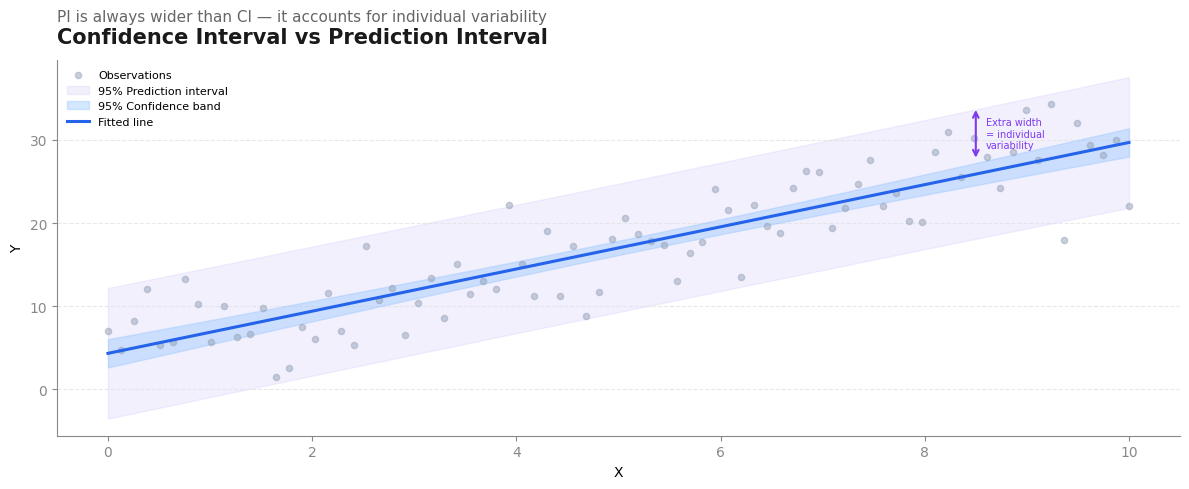

In [4]:
chart = (
    ChartBuilder(figsize=(12, 5))
    .set_title('Confidence Interval vs Prediction Interval')
    .set_subtitle('PI is always wider than CI — it accounts for individual variability')
    .build()
)
ax = chart.ax

ax.scatter(x_reg, y_reg, color='#94A3B8', s=20, alpha=0.5,
           label='Observations', zorder=2)

# PI (outer, wider)
add_prediction_interval(
    ax, x_reg,
    lower=pi_lower, upper=pi_upper,
    color='#C4B5FD', alpha=0.20,
    label='95% Prediction interval',
)

# CI (inner, narrower)
add_confidence_band(
    ax, x_reg, y_fitted,
    lower=ci_lower, upper=ci_upper,
    color='#93C5FD', alpha=0.40,
    label='95% Confidence band',
)

# Fitted line
ax.plot(x_reg, y_fitted, color='#2563EB', linewidth=2.2,
        label='Fitted line', zorder=4)

ax.legend(frameon=False, fontsize=8)
ax.set_xlabel('X'); ax.set_ylabel('Y')

# Annotate difference
x_annotate = 8.5
idx_a = np.searchsorted(x_reg, x_annotate)
ax.annotate('', xy=(x_annotate, pi_upper[idx_a]),
            xytext=(x_annotate, ci_upper[idx_a]),
            arrowprops=dict(arrowstyle='<->', color='#7C3AED', lw=1.5))
ax.text(x_annotate + 0.1, (pi_upper[idx_a] + ci_upper[idx_a]) / 2,
        'Extra width\n= individual\nvariability',
        fontsize=7, color='#7C3AED', va='center')

plt.tight_layout()
plt.show()

## Confidence Interval vs Prediction Interval

Regression chỉ hiển thị fitted line:

$$
\hat y(x)
$$

nhưng thực tế có hai loại uncertainty khác nhau:

- uncertainty của **mean** → Confidence Interval (CI)
- uncertainty của **observation** → Prediction Interval (PI)

---

### Confidence Interval — uncertainty của mean

Confidence band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

CI trả lời:

$$
\mu(x) = \mathbb{E}[Y|X=x]
$$

nằm trong khoảng nào.

Band này hẹp hơn vì chỉ bao gồm uncertainty của estimate.

---

### Prediction Interval — uncertainty của observation

Prediction band:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

PI trả lời:

$$
y_{\text{new}}
$$

nằm trong khoảng nào.

Band rộng hơn vì thêm variability của từng observation.

---

### Vì sao PI rộng hơn CI

Do:

$$
\text{SE}(\hat y)^2 + \sigma^2
>
\text{SE}(\hat y)^2
$$

⇒

$$
\text{Width}_{PI}
>
\text{Width}_{CI}
$$

Khoảng extra width:

$$
\sigma
$$

là **individual variability**.

---

### Interpretation từ chart

- vùng xanh đậm → confidence band
- vùng tím rộng → prediction band
- fitted line → $\hat y(x)$

Quan sát:

- CI hẹp quanh mean
- PI bao phủ hầu hết observations
- extra width = variability của dữ liệu

---

### Khi dùng Confidence Interval

Quan tâm:

$$
\mu(x)
$$

Ví dụ:

- average sales
- mean demand
- expected revenue
- regression trend

---

### Khi dùng Prediction Interval

Quan tâm:

$$
y_{\text{new}}
$$

Ví dụ:

- một customer cụ thể
- một ngày cụ thể
- một transaction
- forecast điểm

---

### Summary

Confidence interval:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Quan hệ:

$$
\text{PI width}
>
\text{CI width}
$$

Interpretation:

- CI → uncertainty của mean
- PI → uncertainty của observation  

## 3. CI vs PI — Side by Side Comparison

Hiển thị **Confidence Interval (CI)** và **Prediction Interval (PI)** trong cùng
một chart tạo hiệu ứng **nested bands**.

Regression mean:

$$
\hat y(x)
$$

Hai lớp uncertainty:

- Inner band → CI
- Outer band → PI

---

### Confidence Interval (Inner Band)

Confidence band:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

CI thể hiện uncertainty của:

$$
\mu(x)
=
\mathbb{E}[Y|X=x]
$$

Band hẹp hơn vì chỉ chứa uncertainty của mean.

---

### Prediction Interval (Outer Band)

Prediction band:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

PI thể hiện uncertainty của:

$$
y_{\text{new}}
$$

Band rộng hơn vì bao gồm **individual variability**.

---

### Quan hệ giữa CI và PI

Do:

$$
\sqrt{
\text{SE}(\hat y)^2
+
\sigma^2
}
>
\text{SE}(\hat y)
$$

⇒

$$
\text{CI} \subset \text{PI}
$$

Inner band luôn nằm trong outer band.

---

### Nested Band Interpretation

Chart hiển thị:

- line: $\hat y(x)$
- inner band: CI
- outer band: PI

Khoảng cách giữa hai band:

$$
\text{PI width} - \text{CI width}
$$

= variability của individual observations.

---

### Lợi ích của visualization này

#### 1. So sánh hai loại uncertainty

Người xem thấy ngay:

- uncertainty của mean
- uncertainty của observation

không cần đọc nhiều chart.

---

#### 2. Thấy độ noise của dữ liệu

Nếu:

$$
\sigma^2 \uparrow
$$

→ outer band rộng hơn nhiều so với inner band.

Điều này cho thấy dữ liệu noisy.

---

#### 3. Đánh giá reliability của model

Nếu:

- CI hẹp
- PI rất rộng

→ mean chắc chắn nhưng observation biến động lớn.

---

#### 4. Tránh hiểu nhầm CI là prediction range

Nhiều người hiểu sai:

CI = range của điểm mới

Nested bands giúp phân biệt rõ:

- CI → mean
- PI → observation

---

### Summary

Confidence interval:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Visualization:

- inner band = CI
- outer band = PI

Giúp:

- so sánh uncertainty
- thấy noise dữ liệu
- phân biệt mean vs observation
- đọc reliability nhanh

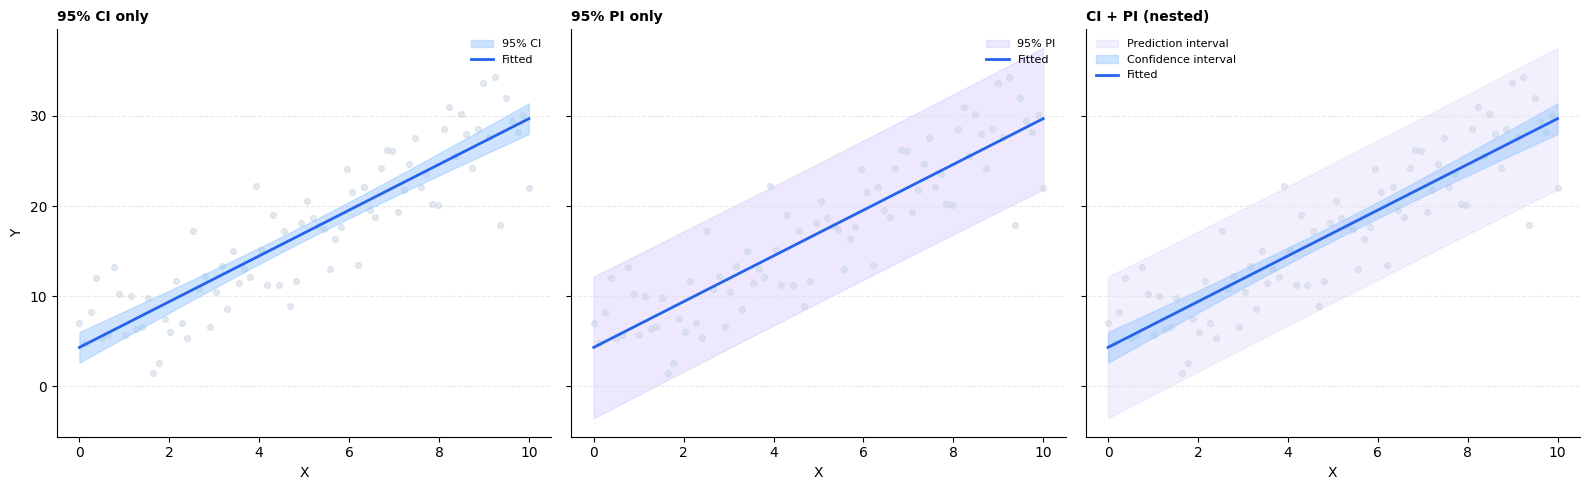

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white', sharey=True)

configs = [
    ('95% CI only',  True,  False),
    ('95% PI only',  False, True),
    ('CI + PI (nested)', True, True),
]

for ax, (title, show_ci, show_pi) in zip(axes, configs):
    ax.scatter(x_reg, y_reg, color='#CBD5E1', s=18, alpha=0.5, zorder=1)

    if show_pi and not show_ci:
        add_prediction_interval(ax, x_reg, pi_lower, pi_upper,
                                color='#C4B5FD', alpha=0.30,
                                label='95% PI')
    elif show_ci and not show_pi:
        add_confidence_band(ax, x_reg, y_fitted, ci_lower, ci_upper,
                            color='#93C5FD', alpha=0.45,
                            label='95% CI')
    elif show_ci and show_pi:
        add_dual_interval(
            ax, x_reg,
            ci_lower=ci_lower, ci_upper=ci_upper,
            pi_lower=pi_lower, pi_upper=pi_upper,
            ci_color='#93C5FD', pi_color='#C4B5FD',
            ci_alpha=0.45, pi_alpha=0.20,
        )

    ax.plot(x_reg, y_fitted, color='#2563EB', linewidth=2.0,
            label='Fitted', zorder=3)
    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('X')
    if ax == axes[0]:
        ax.set_ylabel('Y')
    ax.legend(frameon=False, fontsize=8)
    despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## CI vs PI — Side by Side Comparison

Ba chart minh họa ba cách hiển thị uncertainty:

- CI only
- PI only
- CI + PI (nested)

Regression mean:

$$
\hat y(x)
$$

---

### 1. CI only — Uncertainty của mean

Confidence interval:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

CI cho biết:

$$
\mu(x)
=
\mathbb{E}[Y|X=x]
$$

Quan sát:

- band hẹp
- centered quanh fitted line
- không bao phủ toàn bộ points

Interpretation:

CI **không dùng để dự đoán điểm mới**.

---

### 2. PI only — Uncertainty của observation

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

PI cho biết:

$$
y_{\text{new}}
$$

Quan sát:

- band rộng hơn nhiều
- bao phủ phần lớn observations
- thể hiện variability thật

Interpretation:

PI dùng cho **individual prediction**.

---

### 3. CI + PI — Nested uncertainty

Nested bands:

- inner band → CI
- outer band → PI

Quan hệ:

$$
\text{CI} \subset \text{PI}
$$

Khoảng cách giữa hai band:

$$
\text{PI width} - \text{CI width}
$$

= individual variability.

---

### Lợi ích của visualization side-by-side

#### 1. So sánh trực tiếp CI vs PI

Người xem thấy ngay:

- CI hẹp
- PI rộng
- nested structure

---

#### 2. Phân biệt mean vs observation

CI:

$$
\mu(x)
$$

PI:

$$
y_{\text{new}}
$$

Nested band làm distinction rõ ràng.

---

#### 3. Hiểu cấu trúc uncertainty

Total uncertainty:

$$
\text{Total}
=
\text{Mean uncertainty}
+
\text{Observation noise}
$$

CI = mean uncertainty
PI = total uncertainty

---

### Interpretation

- CI only → dễ hiểu nhầm prediction range
- PI only → không thấy mean certainty
- CI + PI → đầy đủ thông tin

Best practice:

hiển thị **nested bands**.

---

### Summary

Confidence interval:

$$
\hat y(x)
\pm
t
\cdot
\text{SE}(\hat y(x))
$$

Prediction interval:

$$
\hat y(x)
\pm
t
\cdot
\sqrt{
\text{SE}(\hat y(x))^2
+
\sigma^2
}
$$

Visualization:

- CI only → mean uncertainty
- PI only → observation uncertainty
- CI + PI → nested uncertainty

## 4. Forecast Period Shading

Khi chart có cả **historical data** và **forecast**, cần phân biệt rõ hai vùng:

- dữ liệu đã quan sát
- dữ liệu dự báo

Giả sử forecast bắt đầu tại:

$$
t = t_f
$$

Time series:

$$
x_t
=
\begin{cases}
\text{historical} & t \le t_f \\
\text{forecast} & t > t_f
\end{cases}
$$

Forecast period shading tô nền vùng:

$$
t > t_f
$$

để cảnh báo người xem đây là **prediction**, không phải data thật.

---

### Visual Conventions

#### 1. Historical — solid line

Dữ liệu đã quan sát:

$$
x_t \quad (t \le t_f)
$$

hiển thị:

- solid line
- màu đậm
- không shading

---

#### 2. Forecast — dashed line

Dự báo:

$$
\hat x_t \quad (t > t_f)
$$

hiển thị:

- dashed line
- màu nhạt hơn
- uncertainty band (optional)

---

#### 3. Forecast boundary

Điểm phân tách:

$$
t = t_f
$$

được vẽ:

- vertical line
- thường màu tím
- đánh dấu start forecast

---

#### 4. Forecast shading

Forecast region:

$$
t > t_f
$$

được tô nền nhạt để:

- phân biệt historical vs forecast
- tránh hiểu nhầm prediction là data thật
- tăng readability

---

### Khi kết hợp với uncertainty

Forecast thường đi kèm prediction interval:

$$
\hat x_t
\pm
\sigma_t
$$

Band này thường:

- chỉ xuất hiện trong forecast region
- mở rộng theo thời gian

Do:

$$
\text{Var}(\hat x_t) \uparrow \quad \text{when } t \uparrow
$$

---

### Lợi ích của forecast shading

#### 1. Tránh nhầm forecast với history

Không shading:

- người xem tưởng toàn bộ là observed

Có shading:

- forecast được phân biệt rõ

---

#### 2. Nhấn mạnh uncertainty tương lai

Forecast:

$$
\hat x_t
$$

không chắc chắn như historical.

Shading giúp truyền đạt điều này trực quan.

---

#### 3. Cải thiện storytelling

Chart thể hiện:

- quá khứ
- hiện tại
- tương lai

trong cùng một visualization.

---

### Summary

Forecast boundary:

$$
t = t_f
$$

Historical:

$$
t \le t_f
$$

Forecast:

$$
t > t_f
$$

Conventions:

- historical → solid line
- forecast → dashed line
- boundary → vertical line
- forecast → shaded background

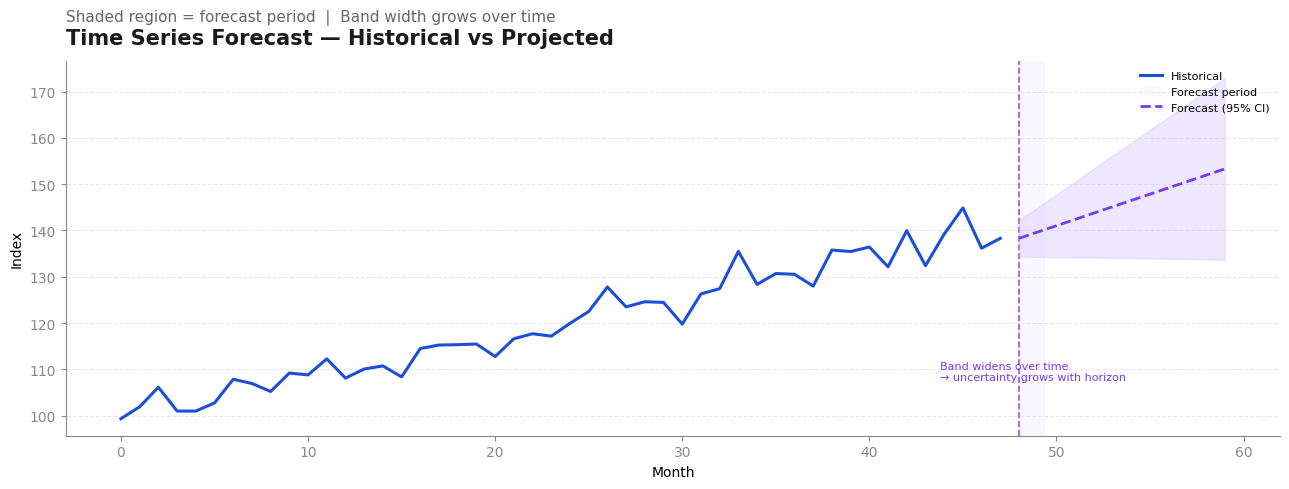

In [6]:
t_all = np.arange(T_total)

chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Time Series Forecast — Historical vs Projected')
    .set_subtitle('Shaded region = forecast period  |  Band width grows over time')
    .build()
)
ax = chart.ax

# Plot historical
ax.plot(t_hist, y_hist, color='#1D4ED8', linewidth=2.2,
        label='Historical', zorder=4)

# Shade forecast period
shade_forecast_period(
    ax, x_start=T_hist,
    color='#F5F3FF', alpha=0.5,
    label='Forecast period',
    linecolor='#7C3AED', linestyle='--', linewidth=1.2,
)

# Plot forecast with uncertainty
add_forecast_region(
    ax, t_fore,
    y_central=y_fore_central,
    lower=fore_ci_lo,
    upper=fore_ci_hi,
    central_color='#7C3AED',
    band_color='#C4B5FD',
    central_linewidth=2.0,
    band_alpha=0.30,
    linestyle='--',
    label='Forecast (95% CI)',
)

ax.set_xlabel('Month')
ax.set_ylabel('Index')
ax.legend(frameon=False, fontsize=8)

add_note(ax, 'Band widens over time\n→ uncertainty grows with horizon',
         x=0.72, y=0.20, color='#7C3AED', fontsize=8)

plt.tight_layout()
plt.show()

## Forecast Period Shading — Historical vs Projected

Chart tách time series thành hai vùng:

Historical:

$$
x_t \quad (t \le t_f)
$$

Forecast:

$$
\hat x_t \quad (t > t_f)
$$

Trong đó:

$$
t_f
$$

là thời điểm bắt đầu forecast.

---

### 1. Historical vs Forecast

Historical:

- solid line
- dữ liệu đã quan sát
- không có shading

Forecast:

- dashed line
- giá trị dự báo
- shaded background

Việc tách này tránh hiểu nhầm:

$$
\hat x_t \neq x_t
$$

Forecast không phải dữ liệu thật.

---

### 2. Forecast Boundary

Điểm phân tách:

$$
t = t_f
$$

được vẽ bằng:

- vertical dashed line
- màu tím
- đánh dấu start forecast

Giúp người xem biết chính xác khi nào bắt đầu prediction.

---

### 3. Forecast Uncertainty

Forecast thường đi kèm prediction interval:

$$
\hat x_t
\pm
\sigma_t
$$

Trong chart:

- band xuất hiện sau boundary
- band mở rộng theo thời gian

Do:

$$
\text{Var}(\hat x_t) \uparrow \quad \text{when } t \uparrow
$$

---

### 4. Band widens over time

Uncertainty forecast tăng theo horizon:

$$
\sigma_t^2
=
\text{Var}(\hat x_t)
$$

Với:

$$
t - t_f \uparrow
$$

⇒

$$
\sigma_t \uparrow
$$

⇒ band mở rộng.

Điều này thể hiện:

- short-term forecast đáng tin hơn
- long-term forecast không chắc chắn

---

### 5. Visual conventions

Historical:

$$
t \le t_f
$$

- solid line
- no shading

Forecast:

$$
t > t_f
$$

- dashed line
- shaded background
- uncertainty band

Boundary:

$$
t = t_f
$$

- vertical line

---

### 6. Lợi ích của visualization này

#### Phân biệt observed vs predicted

$$
x_t \quad vs \quad \hat x_t
$$

---

#### Hiển thị uncertainty tương lai

$$
\text{Var}(\hat x_t)
$$

---

#### Nhấn mạnh forecast horizon

$$
t - t_f
$$

---

#### Tránh overinterpretation

Forecast không chắc chắn như historical.

---

### Summary

Historical:

$$
x_t
\quad t \le t_f
$$

Forecast:

$$
\hat x_t
\quad t > t_f
$$

Prediction band:

$$
\hat x_t \pm \sigma_t
$$

Đặc điểm:

- forecast shaded
- dashed forecast line
- vertical boundary
- band widens over time  

## 5. Uncertainty Grows Over Time

Một hiểu lầm phổ biến khi vẽ forecast là sử dụng **band có độ rộng cố định**,
ngụ ý rằng uncertainty không thay đổi theo horizon.

Flat band:

$$
\hat x_t \pm \sigma
$$

Điều này giả định:

$$
\text{Var}(\hat x_t) = \sigma^2
\quad \text{constant}
$$

→ sai với hầu hết time series.

---

### Random Walk Assumption

Với random walk:

$$
x_t = x_{t-1} + \epsilon_t
$$

trong đó:

$$
\epsilon_t \sim \mathcal{N}(0,\sigma^2)
$$

Forecast $h$ bước:

$$
\hat x_{t+h}
$$

Variance:

$$
\text{Var}(\hat x_{t+h})
=
h \sigma^2
$$

Standard deviation:

$$
\sigma_h
=
\sigma \sqrt{h}
$$

---

### Growing Forecast Band

Prediction interval:

$$
\hat x_{t+h}
\pm
z
\cdot
\sigma \sqrt{h}
$$

Band width:

$$
\propto \sqrt{h}
$$

⇒ band mở rộng theo thời gian.

---

### Flat Band — Sai

Flat band:

$$
\hat x_{t+h}
\pm
z\sigma
$$

Không phụ thuộc $h$.

Ngụ ý:

- long-term forecast chắc như short-term
- uncertainty không tăng

Điều này không đúng.

---

### Growing Band — Đúng

Growing band:

$$
\hat x_{t+h}
\pm
z\sigma\sqrt{h}
$$

Đặc điểm:

- hẹp gần forecast start
- rộng dần theo horizon
- phản ánh uncertainty tích lũy

---

### Intuition

Noise tích lũy theo thời gian:

$$
x_{t+h}
=
x_t
+
\sum_{i=1}^{h} \epsilon_i
$$

Variance:

$$
\text{Var}
\left(
\sum_{i=1}^{h} \epsilon_i
\right)
=
h\sigma^2
$$

⇒ uncertainty tăng theo $h$.

---

### Visual Interpretation

Near-term forecast:

$$
h \approx 0
$$

⇒ band hẹp

Long-term forecast:

$$
h \uparrow
$$

⇒ band rộng

---

### Summary

Flat band (sai):

$$
\hat x_{t+h} \pm \sigma
$$

Growing band (đúng):

$$
\hat x_{t+h}
\pm
\sigma \sqrt{h}
$$

Kết luận:

- uncertainty tăng theo horizon
- band phải mở rộng theo thời gian
- flat band gây overconfidence

C:\Users\Duy\AppData\Local\Temp\ipykernel_10584\1017284730.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


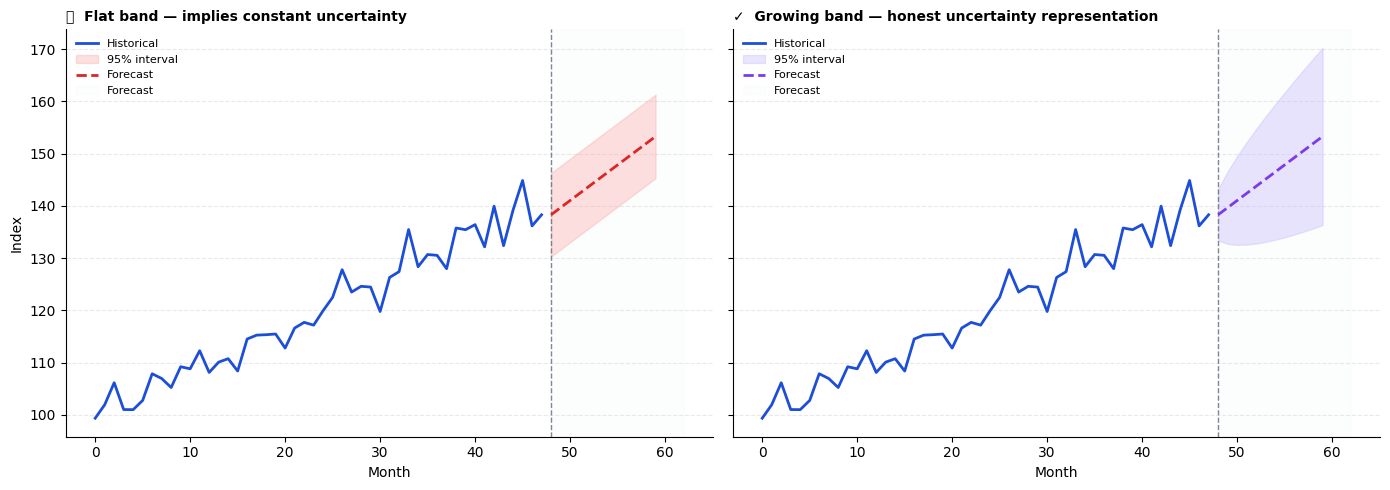

In [7]:
h = np.arange(1, T_fore + 1)  # forecast horizon steps

# Flat (incorrect) uncertainty
flat_width = 8.0
flat_lo = y_fore_central - flat_width
flat_hi = y_fore_central + flat_width

# Growing (correct) uncertainty — σ grows with sqrt(h)
base_sigma = 2.5
grow_width = base_sigma * np.sqrt(h)
grow_lo = y_fore_central - 1.96 * grow_width
grow_hi = y_fore_central + 1.96 * grow_width

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white', sharey=True)

for ax, (lo, hi), title, band_color, is_wrong in zip(
    axes,
    [(flat_lo, flat_hi), (grow_lo, grow_hi)],
    ['Flat band — implies constant uncertainty',
     'Growing band — honest uncertainty representation'],
    ['#FCA5A5', '#C4B5FD'],
    [True, False],
):
    # Historical
    ax.plot(t_hist, y_hist, color='#1D4ED8', linewidth=2.0, label='Historical')

    # Forecast region
    ax.fill_between(t_fore, lo, hi, color=band_color, alpha=0.35,
                    label='95% interval')
    ax.plot(t_fore, y_fore_central,
            color='#DC2626' if is_wrong else '#7C3AED',
            linewidth=2.0, linestyle='--', label='Forecast')

    shade_forecast_period(ax, T_hist, color='#F8FAFC', alpha=0.4,
                          linecolor='#6B7280', linewidth=1.0)

    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('Month')
    if ax == axes[0]:
        ax.set_ylabel('Index')
    ax.legend(frameon=False, fontsize=8)
    despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Uncertainty Grows Over Time — Flat vs Growing Band

Forecast tại horizon $h$:

$$
\hat x_{t+h}
$$

Uncertainty của forecast không cố định mà **tăng theo thời gian**.

Hai cách hiển thị:

- Flat band — sai
- Growing band — đúng

---

### Flat Band — Constant Uncertainty (Sai)

Flat band giả định:

$$
\hat x_{t+h}
\pm
\sigma
$$

Điều này tương đương:

$$
\text{Var}(\hat x_{t+h}) = \sigma^2
$$

không phụ thuộc horizon.

Ngụ ý sai:

- short-term = long-term certainty
- uncertainty không tích lũy
- forecast dài hạn đáng tin như ngắn hạn

→ overconfident forecast.

---

### Growing Band — Uncertainty Tăng Theo Horizon (Đúng)

Với random walk:

$$
x_t = x_{t-1} + \epsilon_t
$$

$$
\epsilon_t \sim (0,\sigma^2)
$$

Forecast:

$$
x_{t+h}
=
x_t
+
\sum_{i=1}^{h} \epsilon_i
$$

Variance:

$$
\text{Var}(x_{t+h})
=
h\sigma^2
$$

Standard deviation:

$$
\sigma_h
=
\sigma\sqrt{h}
$$

Prediction band:

$$
\hat x_{t+h}
\pm
z\sigma\sqrt{h}
$$

---

### Interpretation từ hình

Flat band:

- width không đổi
- uncertainty constant
- không thực tế

Growing band:

- hẹp gần boundary
- rộng dần theo horizon
- uncertainty tăng theo thời gian

---

### Intuition

Noise tích lũy:

$$
\epsilon_1 + \epsilon_2 + \cdots + \epsilon_h
$$

Variance cộng dồn:

$$
\sigma^2 + \sigma^2 + \cdots = h\sigma^2
$$

⇒ band phải mở rộng.

---

### Khi forecast xa hơn

Near-term:

$$
h \approx 1
$$

⇒ band hẹp

Long-term:

$$
h \gg 1
$$

⇒ band rộng

---

### Summary

Flat band (sai):

$$
\hat x_{t+h} \pm \sigma
$$

Growing band (đúng):

$$
\hat x_{t+h}
\pm
\sigma\sqrt{h}
$$

Kết luận:

- uncertainty tăng theo thời gian
- band phải mở rộng
- flat band gây overconfidence  

## 6. Fan Chart — Multi-Quantile Uncertainty

Fan chart (cone of uncertainty) hiển thị **nhiều quantile forecast** cùng lúc,
thay vì chỉ một prediction band.

Forecast distribution tại horizon $h$:

$$
X_{t+h}
\sim
F_{t+h}(x)
$$

Fan chart vẽ nhiều quantile:

$$
q_{\alpha}(t+h)
=
F^{-1}_{t+h}(\alpha)
$$

---

### Multi-Quantile Bands

Các band thường dùng:

Outer band (80%):

$$
[q_{0.10}, q_{0.90}]
$$

Middle band (60%):

$$
[q_{0.20}, q_{0.80}]
$$

Inner band (40%):

$$
[q_{0.30}, q_{0.70}]
$$

Central forecast:

$$
q_{0.50}
$$

---

### Median Forecast

Đường giữa:

$$
\tilde x_{t+h}
=
q_{0.50}
$$

Median được dùng thay mean vì:

- robust với skew
- phù hợp distribution bất đối xứng
- chuẩn trong macro forecast

---

### Quantile Interpretation

Outer band:

$$
P(q_{0.10} \le X \le q_{0.90}) = 0.8
$$

Middle band:

$$
P(q_{0.20} \le X \le q_{0.80}) = 0.6
$$

Inner band:

$$
P(q_{0.30} \le X \le q_{0.70}) = 0.4
$$

Band càng trong → certainty cao hơn.

---

### Vì sao dùng nhiều quantile

Single interval:

$$
\hat x \pm \sigma
$$

không cho biết:

- distribution shape
- skewness
- tail risk

Fan chart hiển thị:

$$
F_{t+h}(x)
$$

toàn bộ uncertainty structure.

---

### Growing Fan

Fan chart mở rộng theo horizon:

$$
\text{Var}(X_{t+h}) \uparrow
$$

⇒ quantile spread tăng:

$$
q_{0.90} - q_{0.10} \uparrow
$$

---

### Khi distribution skewed

Nếu:

$$
q_{0.50} - q_{0.10}
\neq
q_{0.90} - q_{0.50}
$$

→ uncertainty bất đối xứng

Fan chart hiển thị skew rõ ràng.

---

### Lợi ích của Fan Chart

#### 1. Hiển thị toàn bộ uncertainty

Không chỉ một band:

$$
[\text{lower}, \text{upper}]
$$

mà nhiều mức confidence.

---

#### 2. Thấy tail risk

Extreme quantiles:

$$
q_{0.05}, q_{0.95}
$$

thể hiện worst-case scenarios.

---

#### 3. Thấy distribution shape

Symmetric:

$$
q_{0.90} - q_{0.50}
=
q_{0.50} - q_{0.10}
$$

Skewed:

không bằng nhau.

---

#### 4. Chuẩn trong macro forecast

Fan chart được dùng bởi:

- central banks
- inflation forecast
- GDP forecast
- policy uncertainty

---

### Summary

Fan chart vẽ quantiles:

$$
q_{\alpha}(t+h)
$$

Các band:

$$
[q_{0.10}, q_{0.90}]
$$

$$
[q_{0.20}, q_{0.80}]
$$

$$
[q_{0.30}, q_{0.70}]
$$

Central forecast:

$$
q_{0.50}
$$

Giúp:

- hiển thị multi-level uncertainty
- thấy tail risk
- thấy skew
- trực quan distribution forecast

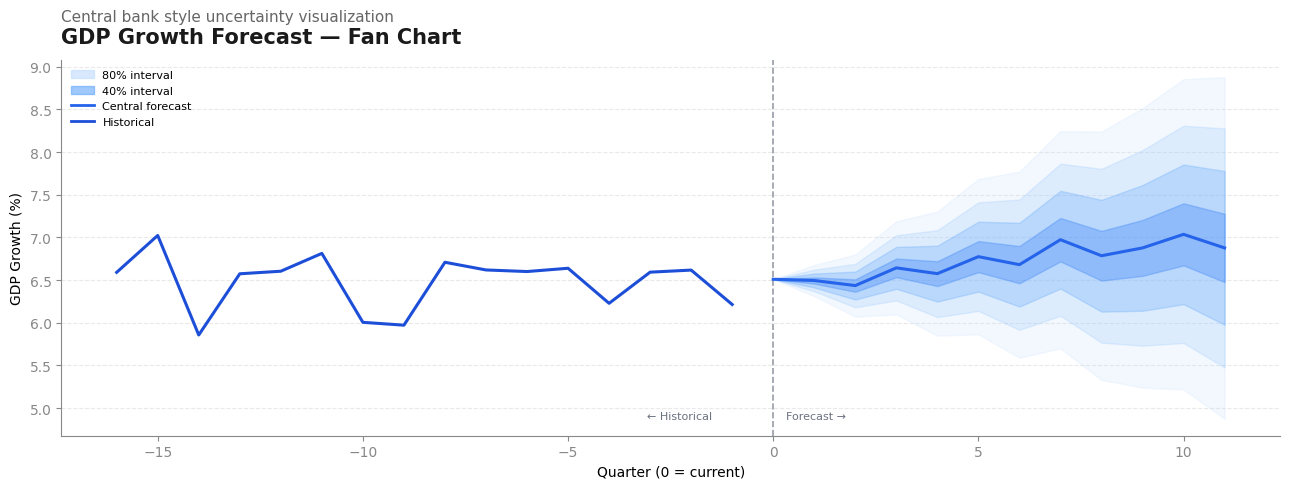

In [8]:
# Historical GDP growth (trước forecast)
T_hist_gdp = 16
t_hist_gdp = np.arange(-T_hist_gdp, 0)
y_hist_gdp = 6.5 + np.random.randn(T_hist_gdp) * 0.4

chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('GDP Growth Forecast — Fan Chart')
    .set_subtitle('Central bank style uncertainty visualization')
    .build()
)
ax = chart.ax

# Historical
ax.plot(t_hist_gdp, y_hist_gdp,
        color='#1D4ED8', linewidth=2.2, label='Historical')

# Fan chart — quantile pairs: (q10,q90), (q20,q80), (q30,q70), (q40,q60)
fan_chart(
    ax, t_fan,
    quantile_df=quantile_data,
    center_col='q50',
    quantile_pairs=[
        ('q10', 'q90'),
        ('q20', 'q80'),
        ('q30', 'q70'),
        ('q40', 'q60'),
    ],
    palette=['#BFDBFE', '#93C5FD', '#60A5FA', '#3B82F6'],
    alpha_base=0.18,
    center_color='#2563EB',
    center_linewidth=2.2,
    label_prefix='',
)

# Add divider at t=0
ax.axvline(0, color='#6B7280', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(0.3, ax.get_ylim()[0] + 0.2, 'Forecast →',
        fontsize=8, color='#6B7280')
ax.text(-1.5, ax.get_ylim()[0] + 0.2, '← Historical',
        fontsize=8, color='#6B7280', ha='right')

ax.set_xlabel('Quarter (0 = current)')
ax.set_ylabel('GDP Growth (%)')

# Legend patches
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color='#BFDBFE', alpha=0.6, label='80% interval'),
    mpatches.Patch(color='#60A5FA', alpha=0.6, label='40% interval'),
    plt.Line2D([0], [0], color='#2563EB', linewidth=2, label='Central forecast'),
    plt.Line2D([0], [0], color='#1D4ED8', linewidth=2, label='Historical'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## Fan Chart — Multi-Quantile Forecast Interpretation

Fan chart hiển thị forecast distribution qua nhiều quantile:

Median forecast:

$$
q_{0.50}(t)
$$

Inner band (40%):

$$
[q_{0.30}(t), q_{0.70}(t)]
$$

Outer band (80%):

$$
[q_{0.10}(t), q_{0.90}(t)]
$$

Các band lồng nhau tạo thành **cone of uncertainty**.

---

### 1. Central Forecast (Median)

Đường giữa:

$$
\tilde x_t = q_{0.50}(t)
$$

Đây là:

- median forecast
- kịch bản trung tâm
- không bị ảnh hưởng bởi skew

Từ chart:

- GDP forecast tăng nhẹ
- trend upward nhẹ
- không có structural jump

---

### 2. Inner Band — High Confidence Region

Inner band:

$$
[q_{0.30}, q_{0.70}]
$$

Probability:

$$
P(X_t \in \text{inner band}) = 0.4
$$

Interpretation:

- vùng likely nhất
- high-confidence forecast
- narrow uncertainty

---

### 3. Outer Band — Full Uncertainty

Outer band:

$$
[q_{0.10}, q_{0.90}]
$$

Probability:

$$
P(X_t \in \text{outer band}) = 0.8
$$

Interpretation:

- full forecast range
- tail risk
- extreme scenarios

---

### 4. Uncertainty grows over horizon

Fan mở rộng theo thời gian:

$$
\text{Var}(X_{t+h}) \uparrow
$$

⇒

$$
q_{0.90} - q_{0.10} \uparrow
$$

Từ chart:

- gần forecast start → band hẹp
- xa hơn → band rộng

---

### 5. Symmetry của forecast distribution

Nếu:

$$
q_{0.50} - q_{0.10}
\approx
q_{0.90} - q_{0.50}
$$

→ distribution symmetric

Chart cho thấy:

- fan gần symmetric
- uncertainty cân đối
- không skew mạnh

---

### 6. Historical vs Forecast

Historical:

$$
t < 0
$$

Forecast:

$$
t \ge 0
$$

Boundary:

$$
t = 0
$$

Fan bắt đầu tại boundary.

---

### 7. Interpretation từ hình

- GDP growth trung tâm tăng nhẹ
- uncertainty tăng theo horizon
- short-term khá chắc chắn
- long-term spread rộng
- tail risk tăng theo thời gian

---

### Summary

Fan chart quantiles:

Median:

$$
q_{0.50}
$$

Inner band:

$$
[q_{0.30}, q_{0.70}]
$$

Outer band:

$$
[q_{0.10}, q_{0.90}]
$$

Interpretation:

- center = median forecast
- inner = high confidence
- outer = full uncertainty
- fan widens over time  

## 7. Scenario Analysis — Best / Base / Worst

Scenario analysis biểu diễn uncertainty bằng **các kịch bản rời rạc** thay vì
continuous probabilistic band.

Forecast trở thành nhiều trajectories:

$$
x_t^{(\text{best})}, \quad
x_t^{(\text{base})}, \quad
x_t^{(\text{worst})}
$$

Trong đó:

- Best (Bull) → optimistic path
- Base → most likely path
- Worst (Bear) → pessimistic path

---

### Base Scenario — Central Case

Base scenario:

$$
x_t^{(\text{base})}
$$

Thường tương đương:

$$
\mathbb{E}[X_t]
\quad \text{hoặc} \quad
q_{0.50}(t)
$$

Interpretation:

- expected trajectory
- most likely outcome
- central forecast

---

### Best Case — Bull Scenario

Best case:

$$
x_t^{(\text{best})}
=
x_t^{(\text{base})}
+
\Delta_t^{+}
$$

Trong đó:

$$
\Delta_t^{+} > 0
$$

Phản ánh:

- demand tăng
- policy thuận lợi
- cost giảm
- growth acceleration

---

### Worst Case — Bear Scenario

Worst case:

$$
x_t^{(\text{worst})}
=
x_t^{(\text{base})}
-
\Delta_t^{-}
$$

Trong đó:

$$
\Delta_t^{-} > 0
$$

Phản ánh:

- recession
- shock
- supply disruption
- negative policy

---

### Scenario Envelope

Khoảng scenario:

$$
x_t^{(\text{worst})}
\le
x_t
\le
x_t^{(\text{best})}
$$

Khác với probabilistic band:

- không phải confidence interval
- không phải prediction interval
- là **narrative-driven range**

---

### Khi nên dùng Scenario Analysis

Scenario analysis phù hợp khi uncertainty:

Không continuous:

$$
\text{uncertainty} \not\sim \text{Gaussian}
$$

Mà đến từ discrete events:

- policy change
- war
- regulation
- supply shock
- product launch

---

### Scenario vs Statistical Bands

Statistical band:

$$
\hat x_t \pm \sigma_t
$$

Scenario:

$$
x_t^{(\text{worst})},
x_t^{(\text{base})},
x_t^{(\text{best})}
$$

Statistical band:

- continuous uncertainty
- probabilistic
- technical

Scenario:

- discrete outcomes
- narrative-based
- dễ hiểu

---

### Visual Conventions

Base:

- solid line
- central color

Best:

- upper line
- optimistic color

Worst:

- lower line
- pessimistic color

---

### Interpretation

Nếu:

$$
x_t^{(\text{best})}
-
x_t^{(\text{worst})}
\uparrow
$$

→ uncertainty tăng theo thời gian.

Nếu:

paths diverge:

→ long-term uncertainty lớn.

---

### Summary

Scenario paths:

$$
x_t^{(\text{best})}
$$

$$
x_t^{(\text{base})}
$$

$$
x_t^{(\text{worst})}
$$

Envelope:

$$
x_t^{(\text{worst})}
\le
x_t
\le
x_t^{(\text{best})}
$$

Giúp:

- biểu diễn discrete uncertainty
- gắn narrative cho từng case
- dễ hiểu cho non-technical audience

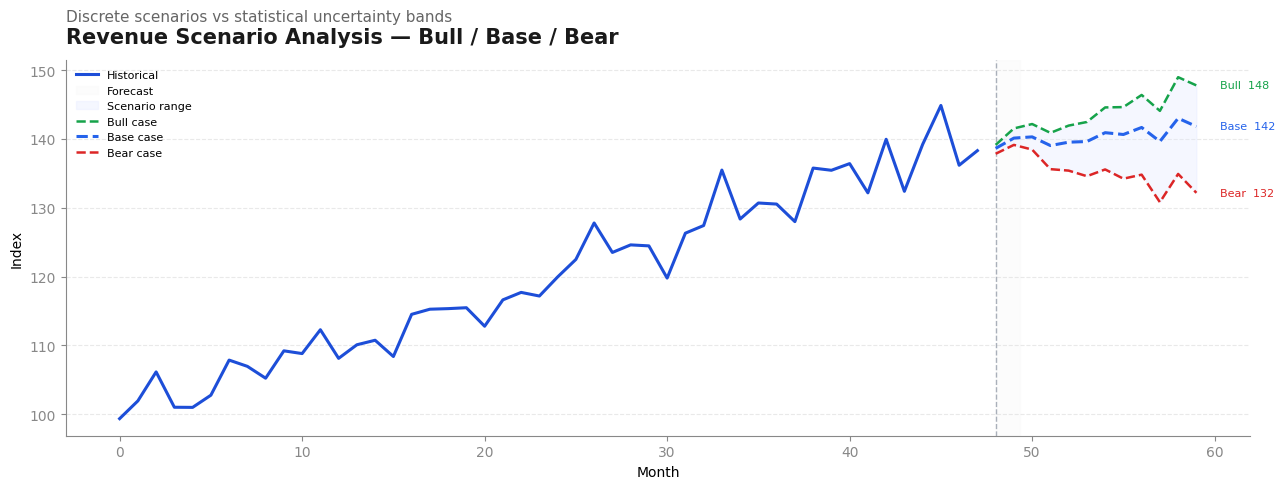

In [9]:
# 3 scenarios từ base forecast
rng = np.random.default_rng(11)

bull_drift  = +0.8   # tháng
base_drift  =  0.3
bear_drift  = -0.5

scenario_noise = rng.normal(0, 1.5, T_fore)

y_bull  = y_hist[-1] + np.cumsum(np.ones(T_fore) * bull_drift) + scenario_noise * 0.8
y_base  = y_hist[-1] + np.cumsum(np.ones(T_fore) * base_drift) + scenario_noise * 0.6
y_bear  = y_hist[-1] + np.cumsum(np.ones(T_fore) * bear_drift) + scenario_noise * 0.9

chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Revenue Scenario Analysis — Bull / Base / Bear')
    .set_subtitle('Discrete scenarios vs statistical uncertainty bands')
    .build()
)
ax = chart.ax

# Historical
ax.plot(t_hist, y_hist, color='#1D4ED8', linewidth=2.2, label='Historical')

# Forecast period shading
shade_forecast_period(ax, T_hist, color='#FAFAFA', alpha=0.6,
                      linecolor='#9CA3AF', linewidth=1.0)

# Fill between bull and bear
ax.fill_between(t_fore, y_bear, y_bull,
                color='#E0E7FF', alpha=0.3, label='Scenario range')

# Three scenario lines
ax.plot(t_fore, y_bull, color='#16A34A', linewidth=1.8,
        linestyle='--', label='Bull case')
ax.plot(t_fore, y_base, color='#2563EB', linewidth=2.2,
        linestyle='--', label='Base case')
ax.plot(t_fore, y_bear, color='#DC2626', linewidth=1.8,
        linestyle='--', label='Bear case')

# Label endpoints
for y_end, label, color in [
    (y_bull[-1], f'Bull  {y_bull[-1]:.0f}', '#16A34A'),
    (y_base[-1], f'Base  {y_base[-1]:.0f}', '#2563EB'),
    (y_bear[-1], f'Bear  {y_bear[-1]:.0f}', '#DC2626'),
]:
    ax.text(T_total + 0.3, y_end, label,
            va='center', fontsize=8, color=color)

ax.set_xlabel('Month')
ax.set_ylabel('Index')
ax.legend(frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## Scenario Analysis — Best / Base / Worst

Scenario analysis biểu diễn forecast bằng các **kịch bản rời rạc** thay vì
continuous uncertainty band.

Forecast paths:

$$
x_t^{(\text{bull})}, \quad
x_t^{(\text{base})}, \quad
x_t^{(\text{bear})}
$$

Trong đó:

- Bull → optimistic outcome
- Base → most likely
- Bear → pessimistic outcome

---

### 1. Base Case — Most Likely Path

Base forecast:

$$
x_t^{(\text{base})}
$$

Đây là:

- central scenario
- expected growth
- reference trajectory

Từ chart:

- base tiếp tục trend tăng nhẹ
- growth ổn định
- không có shock lớn

---

### 2. Bull Case — Upside Scenario

Bull path:

$$
x_t^{(\text{bull})}
=
x_t^{(\text{base})}
+
\Delta_t^{+}
$$

Với:

$$
\Delta_t^{+} > 0
$$

Từ chart:

- tăng nhanh hơn base
- slope lớn hơn
- upside potential ~148

Interpretation:

- demand mạnh
- market expansion
- favorable conditions

---

### 3. Bear Case — Downside Scenario

Bear path:

$$
x_t^{(\text{bear})}
=
x_t^{(\text{base})}
-
\Delta_t^{-}
$$

Với:

$$
\Delta_t^{-} > 0
$$

Từ chart:

- flat hoặc giảm nhẹ
- downside risk ~132
- divergence khỏi base

Interpretation:

- slowdown
- negative shock
- demand giảm

---

### 4. Scenario Envelope

Scenario range:

$$
x_t^{(\text{bear})}
\le
x_t
\le
x_t^{(\text{bull})}
$$

Vùng này:

- không phải confidence interval
- không phải probabilistic band
- là narrative-driven range

---

### 5. Divergence Over Time

Khoảng cách giữa scenarios:

$$
x_t^{(\text{bull})}
-
x_t^{(\text{bear})}
$$

Tăng theo thời gian:

- near-term → gần nhau
- long-term → diverge

⇒ uncertainty dài hạn lớn hơn.

---

### 6. Historical vs Scenario Forecast

Historical:

$$
t < t_f
$$

Scenario forecast:

$$
t \ge t_f
$$

Boundary:

$$
t = t_f
$$

Sau boundary:

- 3 trajectories
- discrete uncertainty
- narrative-based outcomes

---

### 7. Interpretation từ chart

- historical trend tăng
- base: tiếp tục tăng nhẹ
- bull: tăng mạnh hơn
- bear: stagnation / giảm nhẹ
- scenarios diverge theo horizon

---

### Summary

Scenario paths:

$$
x_t^{(\text{bull})}
$$

$$
x_t^{(\text{base})}
$$

$$
x_t^{(\text{bear})}
$$

Range:

$$
x_t^{(\text{bear})}
\le
x_t
\le
x_t^{(\text{bull})}
$$

Giúp:

- biểu diễn discrete uncertainty
- gắn narrative cho từng case
- so sánh upside / downside
- dễ hiểu cho non-technical audience  

## 8. Honest vs Misleading Forecast Charts

Cùng một forecast:

$$
\hat x_{t+h}
$$

có thể được visualize theo nhiều cách với mức độ **honesty** khác nhau.

---

### 1. Point Forecast Only — Ẩn Uncertainty

Chỉ hiển thị:

$$
\hat x_{t+h}
$$

Không có band:

$$
\text{Var}(\hat x_{t+h})
$$

bị ẩn hoàn toàn.

Vấn đề:

- tạo cảm giác certainty giả
- không thấy risk
- không thấy forecast error

→ misleading.

---

### 2. Flat Band — Uncertainty Constant (Sai)

Flat band:

$$
\hat x_{t+h}
\pm
\sigma
$$

Ngụ ý:

$$
\text{Var}(\hat x_{t+h}) = \sigma^2
$$

không phụ thuộc horizon.

Trong thực tế:

$$
\text{Var}(\hat x_{t+h}) \uparrow
$$

⇒ flat band underestimates long-term uncertainty.

---

### 3. Truncated Y-axis — Phóng đại biến động

Truncated axis:

$$
y_{\min} \gg 0
$$

Scale bị thu hẹp:

$$
\Delta y \text{ visual} \uparrow
$$

Hệ quả:

- biến động nhỏ trông lớn
- slope bị exaggerate
- misleading narrative

---

### 4. Full Honest Forecast — Best Practice

Honest forecast hiển thị:

Forecast:

$$
\hat x_{t+h}
$$

Growing uncertainty:

$$
\hat x_{t+h}
\pm
\sigma \sqrt{h}
$$

Proper axis:

$$
y_{\min} \approx \text{data range}
$$

Clear boundary:

$$
t = t_f
$$

Labeling:

- historical
- forecast
- interval

---

### So sánh 4 cách

Point only:

$$
\hat x
$$

→ no uncertainty

Flat band:

$$
\hat x \pm \sigma
$$

→ constant uncertainty

Truncated axis:

visual distortion

Honest:

$$
\hat x_{t+h}
\pm
\sigma\sqrt{h}
$$

→ realistic uncertainty

---

### Nguyên tắc Honest Forecast

1. Luôn hiển thị uncertainty:

$$
\text{Var}(\hat x_t)
$$

2. Band phải mở rộng:

$$
\sigma_h \propto \sqrt{h}
$$

3. Không truncate axis

4. Phân biệt historical vs forecast

---

### Summary

Misleading:

- point forecast only
- flat band
- truncated axis

Honest:

$$
\hat x_{t+h}
\pm
\sigma\sqrt{h}
$$

với:

- growing band
- proper axis
- clear labeling

C:\Users\Duy\AppData\Local\Temp\ipykernel_10584\3737092906.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


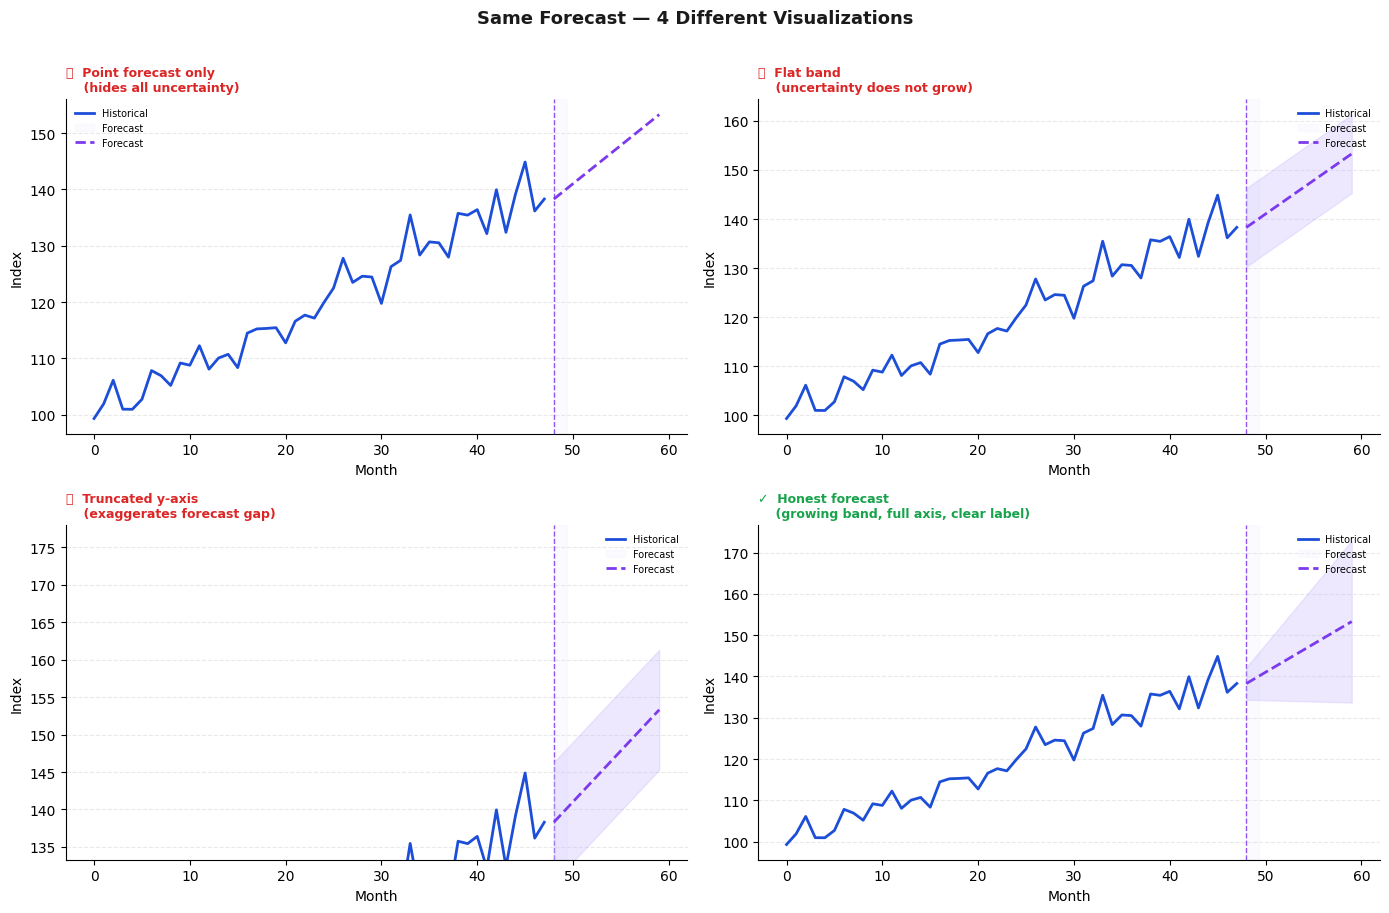

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='white')
axes_flat = axes.flatten()

configs = [
    ('Point forecast only\n    (hides all uncertainty)',
     False, False, None),
    (' Flat band\n    (uncertainty does not grow)',
     True, False, None),
    ('Truncated y-axis\n    (exaggerates forecast gap)',
     True, True, (y_hist[-1] - 5, y_fore_central[-1] + fore_ci_hi[-1] - y_fore_central[-1] + 5)),
    ('Honest forecast\n    (growing band, full axis, clear label)',
     True, False, None),
]

for ax, (title, show_band, truncate, ylim) in zip(axes_flat, configs):
    ax.plot(t_hist, y_hist, color='#1D4ED8', linewidth=2.0, label='Historical')
    shade_forecast_period(ax, T_hist, color='#F5F3FF', alpha=0.4,
                          linecolor='#7C3AED', linewidth=1.0)

    if show_band:
        is_last = title.startswith('✓')
        lo = fore_ci_lo if is_last else y_fore_central - flat_width
        hi = fore_ci_hi if is_last else y_fore_central + flat_width
        ax.fill_between(t_fore, lo, hi,
                        color='#C4B5FD', alpha=0.30)

    ax.plot(t_fore, y_fore_central, color='#7C3AED',
            linewidth=2.0, linestyle='--', label='Forecast')

    if truncate and ylim:
        ax.set_ylim(ylim)

    ax.set_title(title, loc='left', fontsize=9, fontweight='bold',
                 color='#DC2626' if title.startswith('X') else '#16A34A')
    ax.set_xlabel('Month'); ax.set_ylabel('Index')
    ax.legend(frameon=False, fontsize=7)
    despine(ax); set_grid(ax)

plt.suptitle('Same Forecast — 4 Different Visualizations',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.01)
plt.tight_layout()
plt.show()

## Honest vs Misleading Forecast Charts

Cùng một forecast:

$$
\hat x_{t+h}
$$

nhưng cách visualize khác nhau có thể tạo **impression hoàn toàn khác**.

Bốn phiên bản thể hiện mức độ honesty khác nhau.

---

### 1. Point Forecast Only — Hides Uncertainty

Chỉ hiển thị:

$$
\hat x_{t+h}
$$

Không có:

$$
\text{Var}(\hat x_{t+h})
$$

Vấn đề:

- forecast trông chắc chắn tuyệt đối
- không thấy risk
- không thấy range khả dĩ

→ misleading overconfidence

---

### 2. Flat Band — Constant Uncertainty

Flat band:

$$
\hat x_{t+h}
\pm
\sigma
$$

Ngụ ý:

$$
\text{Var}(\hat x_{t+h}) = \sigma^2
$$

không phụ thuộc horizon.

Trong thực tế:

$$
\text{Var}(\hat x_{t+h}) \uparrow
$$

⇒ long-term uncertainty bị **underestimated**.

---

### 3. Truncated Y-axis — Exaggerated Change

Truncated axis:

$$
y_{\min} \uparrow
$$

Scale bị thu hẹp:

$$
\Delta y_{\text{visual}} \gg \Delta y_{\text{actual}}
$$

Hệ quả:

- forecast gap trông lớn hơn
- slope bị exaggerate
- misleading narrative

---

### 4. Honest Forecast — Best Practice

Honest forecast hiển thị:

Central forecast:

$$
\hat x_{t+h}
$$

Growing uncertainty:

$$
\hat x_{t+h}
\pm
\sigma \sqrt{h}
$$

Boundary:

$$
t = t_f
$$

Full axis:

không truncated.

---

### So sánh trực quan

Point only:

$$
\hat x
$$

→ no uncertainty

Flat band:

$$
\hat x \pm \sigma
$$

→ constant uncertainty

Truncated axis:

visual exaggeration

Honest:

$$
\hat x_{t+h}
\pm
\sigma \sqrt{h}
$$

→ realistic uncertainty

---

### Nguyên tắc Honest Forecast

1. Luôn hiển thị uncertainty

$$
\text{Var}(\hat x_t)
$$

2. Band phải mở rộng theo horizon

$$
\sigma_h \propto \sqrt{h}
$$

3. Không truncate y-axis

4. Phân biệt historical vs forecast

---

### Summary

Misleading:

- point forecast only
- flat band
- truncated axis

Honest:

$$
\hat x_{t+h}
\pm
\sigma \sqrt{h}
$$

với:

- growing band
- full axis
- clear boundary
- proper labeling  

## 9. Full Uncertainty Stack — Production Chart

Full uncertainty stack kết hợp tất cả thành phần:

- historical series
- forecast shading
- confidence interval
- prediction interval
- scenario lines
- caption / annotation

Time series:

$$
x_t
$$

Forecast:

$$
\hat x_{t+h}
$$

---

### 1. Historical + Forecast Separation

Boundary:

$$
t = t_f
$$

Historical:

$$
t \le t_f
$$

Forecast:

$$
t > t_f
$$

Visual:

- historical → solid line
- forecast → dashed line
- forecast region → shaded background

---

### 2. Dual Interval (CI + PI)

Confidence interval:

$$
\hat x_{t+h}
\pm
t
\cdot
\text{SE}(\hat x_{t+h})
$$

Prediction interval:

$$
\hat x_{t+h}
\pm
t
\cdot
\sqrt{
\text{SE}(\hat x_{t+h})^2
+
\sigma^2
}
$$

Nested bands:

$$
\text{CI} \subset \text{PI}
$$

---

### 3. Growing Uncertainty

Forecast variance:

$$
\text{Var}(\hat x_{t+h})
=
h\sigma^2
$$

Band width:

$$
\propto \sqrt{h}
$$

⇒ intervals mở rộng theo horizon.

---

### 4. Scenario Lines

Discrete scenarios:

$$
x_t^{(\text{bull})}
$$

$$
x_t^{(\text{base})}
$$

$$
x_t^{(\text{bear})}
$$

Quan hệ:

$$
x_t^{(\text{bear})}
\le
\hat x_t
\le
x_t^{(\text{bull})}
$$

Scenario lines bổ sung narrative uncertainty.

---

### 5. Caption / Annotation

Caption mô tả:

- forecast horizon
- confidence level
- scenario assumptions
- uncertainty interpretation

Ví dụ:

- shaded area = forecast period
- band widens over time
- scenarios show discrete risks

---

### 6. Full Stack Structure

Production chart chứa:

Central forecast:

$$
\hat x_{t+h}
$$

Confidence band:

$$
\hat x \pm \text{SE}
$$

Prediction band:

$$
\hat x \pm \sigma
$$

Scenarios:

$$
\text{bull},\text{base},\text{bear}
$$

Forecast region:

$$
t > t_f
$$

---

### 7. Lợi ích của Full Stack

#### Hiển thị tất cả uncertainty

- statistical
- model
- scenario
- horizon

---

#### Tránh misleading forecast

Không:

- point only
- flat band
- truncated axis

---

#### Production-ready visualization

Dùng cho:

- dashboard
- report
- research paper
- executive presentation

---

### Summary

Full uncertainty stack:

Central:

$$
\hat x_{t+h}
$$

Statistical:

$$
\text{CI}, \text{PI}
$$

Scenario:

$$
\text{bull},\text{base},\text{bear}
$$

Horizon:

$$
t > t_f
$$

Giúp:

- complete uncertainty representation
- honest forecast
- production-ready chart

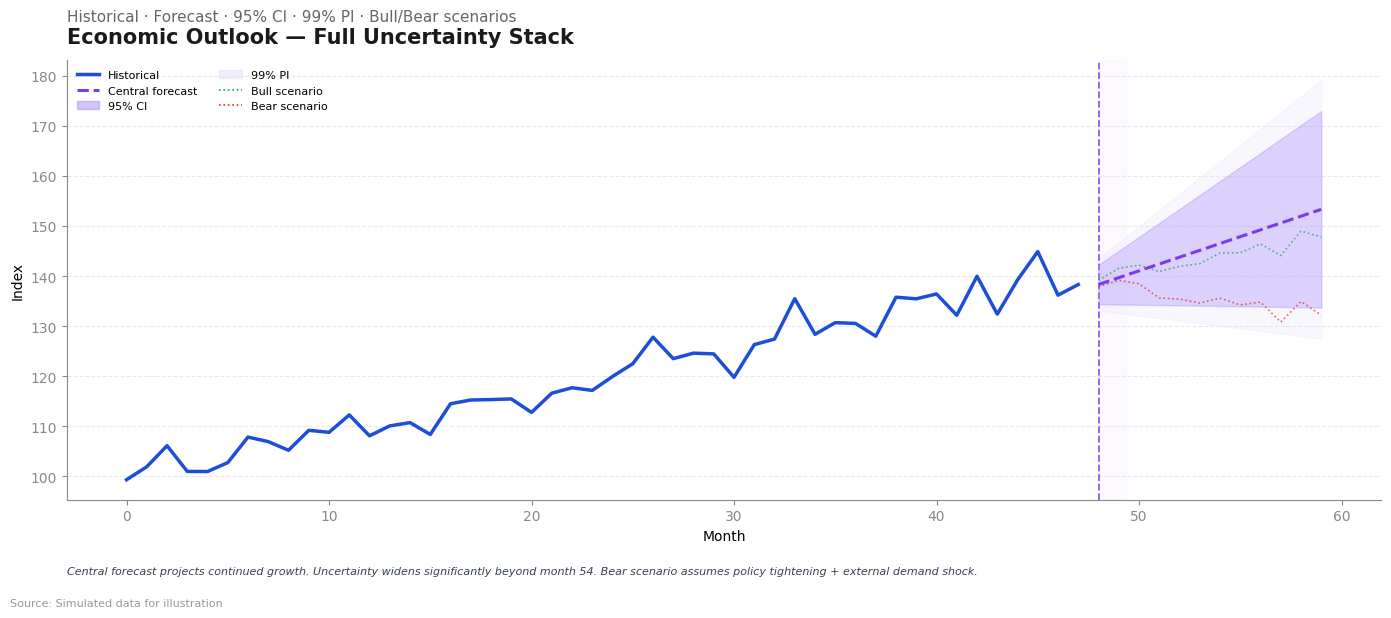

In [11]:
from vizint.annotation import add_caption

chart = (
    ChartBuilder(figsize=(14, 6))
    .set_title('Economic Outlook — Full Uncertainty Stack')
    .set_subtitle('Historical · Forecast · 95% CI · 99% PI · Bull/Bear scenarios')
    .set_source('Simulated data for illustration')
    .build()
)
ax = chart.ax

# Historical
ax.plot(t_hist, y_hist, color='#1D4ED8', linewidth=2.5,
        label='Historical', zorder=5)

# Forecast shading
shade_forecast_period(ax, T_hist, color='#FAF5FF', alpha=0.5,
                      linecolor='#7C3AED', linewidth=1.3)

# Dual interval: PI (outer) + CI (inner)
add_dual_interval(
    ax, t_fore,
    ci_lower=fore_ci_lo, ci_upper=fore_ci_hi,
    pi_lower=fore_pi_lo, pi_upper=fore_pi_hi,
    ci_color='#A78BFA', pi_color='#DDD6FE',
    ci_alpha=0.35, pi_alpha=0.18,
)

# Scenario lines (thin)
ax.plot(t_fore, y_bull, color='#16A34A', linewidth=1.2,
        linestyle=':', alpha=0.7, label='Bull scenario')
ax.plot(t_fore, y_bear, color='#DC2626', linewidth=1.2,
        linestyle=':', alpha=0.7, label='Bear scenario')

# Central forecast
ax.plot(t_fore, y_fore_central, color='#7C3AED', linewidth=2.2,
        linestyle='--', label='Central forecast', zorder=4)

# Legend
import matplotlib.patches as mpatches
legend_elements = [
    plt.Line2D([0],[0], color='#1D4ED8', linewidth=2.5, label='Historical'),
    plt.Line2D([0],[0], color='#7C3AED', linewidth=2.2,
               linestyle='--', label='Central forecast'),
    mpatches.Patch(color='#A78BFA', alpha=0.5, label='95% CI'),
    mpatches.Patch(color='#DDD6FE', alpha=0.4, label='99% PI'),
    plt.Line2D([0],[0], color='#16A34A', linewidth=1.2,
               linestyle=':', label='Bull scenario'),
    plt.Line2D([0],[0], color='#DC2626', linewidth=1.2,
               linestyle=':', label='Bear scenario'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=8,
          loc='upper left', ncol=2)

ax.set_xlabel('Month')
ax.set_ylabel('Index')

add_caption(
    ax,
    'Central forecast projects continued growth. '
    'Uncertainty widens significantly beyond month 54. '
    'Bear scenario assumes policy tightening + external demand shock.',
    y=-0.15, fontsize=8,
)

plt.tight_layout()
plt.show()

## Full Uncertainty Stack — Production Forecast Chart

Full uncertainty stack kết hợp nhiều lớp uncertainty trong một chart:

- historical series
- forecast boundary
- central forecast
- confidence interval (95%)
- prediction interval (99%)
- bull / bear scenarios
- caption narrative

Time series:

$$
x_t
$$

Forecast:

$$
\hat x_{t+h}
$$

---

### 1. Historical vs Forecast

Boundary:

$$
t = t_f
$$

Historical:

$$
t \le t_f
$$

Forecast:

$$
t > t_f
$$

Visual:

- historical → solid line
- forecast → dashed line
- forecast region → shaded background

---

### 2. Central Forecast

Central path:

$$
\hat x_{t+h}
$$

Đây là:

- base case
- expected trajectory
- median forecast

Từ chart:

- trend tiếp tục tăng
- slope ổn định
- không có structural break

---

### 3. Confidence Interval (95%)

Confidence band:

$$
\hat x_{t+h}
\pm
z_{0.95}
\cdot
\text{SE}(\hat x_{t+h})
$$

CI thể hiện uncertainty của:

$$
\mu_{t+h}
=
\mathbb{E}[X_{t+h}]
$$

Band hẹp hơn.

---

### 4. Prediction Interval (99%)

Prediction band:

$$
\hat x_{t+h}
\pm
z_{0.99}
\cdot
\sigma_h
$$

Trong đó:

$$
\sigma_h \propto \sqrt{h}
$$

PI rộng hơn vì bao gồm:

- model uncertainty
- observation noise

Quan hệ:

$$
\text{CI} \subset \text{PI}
$$

---

### 5. Scenario Lines

Bull scenario:

$$
x_t^{(\text{bull})}
$$

Bear scenario:

$$
x_t^{(\text{bear})}
$$

Quan hệ:

$$
x_t^{(\text{bear})}
\le
\hat x_t
\le
x_t^{(\text{bull})}
$$

Scenario bổ sung **discrete risk** ngoài statistical band.

---

### 6. Growing Uncertainty

Forecast variance:

$$
\text{Var}(X_{t+h}) \uparrow
$$

⇒ band mở rộng theo horizon:

$$
\sigma_h \propto \sqrt{h}
$$

Chart cho thấy:

- near-term band hẹp
- long-term band rộng

---

### 7. Interpretation từ hình

- historical trend tăng
- central forecast tiếp tục tăng
- uncertainty tăng theo horizon
- bull scenario: upside growth
- bear scenario: downside shock
- prediction band bao phủ scenarios

---

### 8. Full Stack Structure

Chart chứa:

Central:

$$
\hat x_{t+h}
$$

Statistical:

$$
\text{CI}_{95\%}
$$

$$
\text{PI}_{99\%}
$$

Scenarios:

$$
\text{bull},\text{bear}
$$

Boundary:

$$
t = t_f
$$

---

### Summary

Full uncertainty stack:

Central forecast:

$$
\hat x_{t+h}
$$

Confidence interval:

$$
95\% \text{ CI}
$$

Prediction interval:

$$
99\% \text{ PI}
$$

Scenario:

$$
\text{bull},\text{bear}
$$

Giúp:

- hiển thị statistical uncertainty
- hiển thị scenario risk
- phân biệt historical vs forecast
- production-ready forecast visualization

---
## Summary

| Technique | Function | Dùng khi |
|-----------|----------|----------|
| Confidence band | `add_confidence_band` | Uncertainty của mean estimate |
| Prediction interval | `add_prediction_interval` | Uncertainty của individual observation |
| Nested CI + PI | `add_dual_interval` | Hiển thị cả hai cùng lúc |
| Forecast shading | `shade_forecast_period` | Phân biệt actual vs projected |
| Forecast region | `add_forecast_region` | Central line + band trong forecast |
| Fan chart | `fan_chart` | Multi-quantile uncertainty (central bank style) |
| Scenario analysis | Manual (fill + plot) | Discrete scenarios + narrative |

---

### Key Takeaway

> Ẩn uncertainty không làm forecast trở nên chính xác hơn — nó chỉ làm người xem **thiếu thông tin để ra quyết định tốt**.
>
> Một forecast chart trung thực phải trả lời được:
> - **Trung tâm** là bao nhiêu?
> - **Độ rộng** của uncertainty là bao nhiêu?
> - Uncertainty **tăng như thế nào** theo thời gian?

**Next →** `05_cognitive_load_reduction.ipynb` — Bớt đi để nói nhiều hơn: direct labeling, declutter, và thiết kế để giảm effort của người xem.